**Григорьев Алексей 737-01 automl**

Для automl будем использовать flaml, autogluon и mljar.

Использовать пытался и другие библиотеки, однако с ними возникали проблемы или обучение было идеальным

In [17]:
!pip install --upgrade pip
!pip install flaml autogluon
!pip install mljar-supervised -q

Все библиотеки установились нормально, хоть и есть некоторые конфликты

Импортируем все нужные библиотеки

In [15]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, RocCurveDisplay
import matplotlib.pyplot as plt

from autogluon.tabular import TabularPredictor
from supervised.automl import AutoML as MLAutoML

print("check")

check


Подгружаем данные в дата фрэйм, определяем целевую переменную и создаем дата фрейм без целевой

In [3]:
df = pd.read_csv("dispensarization_data_2026.csv")

target = "Доклинический_риск"
X = df.drop(columns=[target]) #df без целевой
y = df[target]

print("check")

check


Разделяем на обучающую и тестовые выборки (80 на 20), причем со стратификацией, а также разделим признаки на категориальные и числовые

In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = ["Пол_мужской", "Курение", "ССЗ_риск_высокий", "Статус_глюкозы"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print(f"Размер обучающей выборки: {X_train_full.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")
print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numeric_cols)
print("check")

Размер обучающей выборки: 800 объектов
Размер тестовой выборки: 200 объектов
Категориальные признаки: ['Пол_мужской', 'Курение', 'ССЗ_риск_высокий', 'Статус_глюкозы']
Числовые признаки: ['Возраст', 'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Пульсовое_давление', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин', 'Физическая_активность_мин_нед']
check


Заполняем пропуски, для числовых - медиана, для категориальных - мода.

In [10]:
num_imputer = SimpleImputer(strategy="median")
X_train_full[numeric_cols] = num_imputer.fit_transform(X_train_full[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_full[categorical_cols] = cat_imputer.fit_transform(X_train_full[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

for col in categorical_cols:
    X_train_full[col] = X_train_full[col].astype(int)
    X_test[col] = X_test[col].astype(int)

results = {}

print("check")

check


1. Первый automl - AutoGluon

в конце сравним результаты сразу всех automl

In [12]:
train_ag = pd.concat([X_train_full, y_train_full], axis=1)
test_ag = pd.concat([X_test, y_test], axis=1)

start = time.time()
predictor = TabularPredictor(label=target, eval_metric='roc_auc').fit(
    train_data=train_ag,
    time_limit=120,          # 2 минуты
    presets='medium_quality'
)
time_ag = time.time() - start

probs_ag = predictor.predict_proba(test_ag).iloc[:, 1]
preds_ag = predictor.predict(test_ag)

results["AutoGluon"] = {
    "Accuracy": accuracy_score(y_test, preds_ag),
    "ROC-AUC": roc_auc_score(y_test, probs_ag),
    "F1": f1_score(y_test, preds_ag, average='binary'),
    "Time (s)": time_ag,
    "probs": probs_ag
}
print(f"AutoGluon завершён. ROC-AUC = {results['AutoGluon']['ROC-AUC']:.4f}")


No path specified. Models will be saved in: "AutogluonModels/ag-20260528_112133"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.32 GB / 12.67 GB (89.3%)
Disk Space Avail:   75.57 GB / 107.72 GB (70.2%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "/content/AutogluonModels/ag-20260528_112133"
Train Data Rows:    800
Train Data Columns: 17
Label Column:       Доклинический_риск
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is n

AutoGluon завершён. ROC-AUC = 0.9996


2. Второй automl - FLAML

In [13]:
from flaml import AutoML

automl_fl = AutoML()
settings = {
    "time_budget": 120,
    "metric": 'roc_auc',
    "task": 'classification',
    "seed": 42,
    "estimator_list": ['lgbm', 'xgboost', 'catboost', 'rf', 'extra_tree'],
    "eval_method": 'cv',
    "n_splits": 5,
}
start = time.time()
automl_fl.fit(X_train_full.copy(), y_train_full.copy(), **settings)
time_fl = time.time() - start

probs_fl = automl_fl.predict_proba(X_test)[:, 1]
preds_fl = automl_fl.predict(X_test)

results["FLAML"] = {
    "Accuracy": accuracy_score(y_test, preds_fl),
    "ROC-AUC": roc_auc_score(y_test, probs_fl),
    "F1": f1_score(y_test, preds_fl, average='binary'),
    "Time (s)": time_fl,
    "probs": probs_fl
}
print(f"FLAML завершён. ROC-AUC = {results['FLAML']['ROC-AUC']:.4f}")

[flaml.automl.logger: 05-28 11:31:19] {2375} INFO - task = classification
[flaml.automl.logger: 05-28 11:31:19] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-28 11:31:19] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 05-28 11:31:19] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'catboost', 'rf', 'extra_tree']
[flaml.automl.logger: 05-28 11:31:19] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-28 11:31:19] {3046} INFO - Estimated sufficient time budget=1080s. Estimated necessary time budget=2s.
[flaml.automl.logger: 05-28 11:31:19] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.1516e-02,	best estimator lgbm's best error=2.1516e-02
[flaml.automl.logger: 05-28 11:31:19] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-28 11:31:19] {3097} INFO -  at 0.3s,	estimator lgbm's best error=2.1516e-02,	best estimator lgbm's best error=2.1516e-02
[flaml.automl.logger: 05-28 11:31:

3. Третий automl - MLJAR

In [16]:
mljar = MLAutoML(
    mode="Compete",
    eval_metric="auc",          # <-- 'auc', а не 'roc_auc'
    total_time_limit=180,
    random_state=42,
    results_path="mljar_results"
)

start = time.time()
mljar.fit(X_train_full, y_train_full)
time_ml = time.time() - start

probs_ml = mljar.predict_proba(X_test)[:, 1]
preds_ml = mljar.predict(X_test)

results["MLJAR"] = {
    "Accuracy": accuracy_score(y_test, preds_ml),
    "ROC-AUC": roc_auc_score(y_test, probs_ml),
    "F1": f1_score(y_test, preds_ml, average='binary'),
    "Time (s)": time_ml,
    "probs": probs_ml
}
print(f"MLJAR завершён. ROC-AUC = {results['MLJAR']['ROC-AUC']:.4f}")

AutoML directory: mljar_results
The task is binary_classification with evaluation metric auc
AutoML will use algorithms: ['Decision Tree', 'Linear', 'Random Forest', 'Extra Trees', 'LightGBM', 'Xgboost', 'CatBoost', 'Neural Network', 'Nearest Neighbors']
AutoML will stack models
AutoML will ensemble available models
AutoML steps: ['adjust_validation', 'simple_algorithms', 'default_algorithms', 'not_so_random', 'golden_features', 'kmeans_features', 'insert_random_feature', 'features_selection', 'hill_climbing_1', 'hill_climbing_2', 'boost_on_errors', 'ensemble', 'stack', 'ensemble_stacked']
* Step adjust_validation will try to check up to 1 model
1_DecisionTree auc 0.98 trained in 3.33 seconds
Disable stacking for split validation
* Step simple_algorithms will try to check up to 3 models
2_DecisionTree auc 0.96 trained in 2.24 seconds
3_DecisionTree auc 0.96 trained in 2.26 seconds
4_Linear auc 0.944 trained in 7.02 seconds
* Step default_algorithms will try to check up to 7 models
5_De

Результаты. Сравниваем все три результата

          Accuracy   ROC-AUC        F1    Time (s)
AutoGluon     0.99  0.999557  0.909091   42.831355
FLAML         0.99   0.99867  0.909091  120.474932
MLJAR         0.98  0.999113       0.8  194.824227


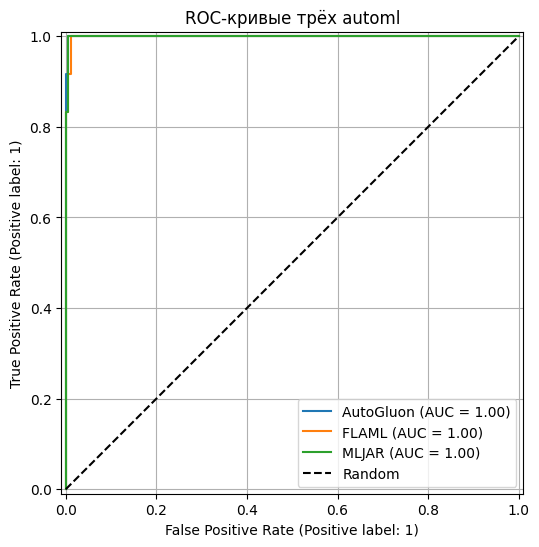

In [20]:
results_df = pd.DataFrame(results).T
print(results_df[["Accuracy", "ROC-AUC", "F1", "Time (s)"]])

plt.figure(figsize=(8,6))
for name, vals in results.items():
    if "probs" in vals:
        RocCurveDisplay.from_predictions(y_test, vals["probs"], name=name, ax=plt.gca())
plt.plot([0,1],[0,1],'k--', label='Random')
plt.title("ROC-кривые трёх automl")
plt.legend()
plt.grid(True)
plt.show()

Значения ROC-AUC превышают 0.998, что говорит о почти идеальной разделяющей способности моделей. (что почти невозможно на реальных данных)

*******************************************
Далее попытка найти колонки, которые приводят к почти идеальному результату по roc-auc

Данные медицинские, следовательно удалять какие-либо из данных может быть опасно для предсказывания, однако цель - эксперимент с данным датасетом

In [22]:
# Копия данных без подозрительных колонок
X_train_no_leak = X_train_full.drop(columns=["Статус_глюкозы", "HbA1c_%"])
X_test_no_leak = X_test.drop(columns=["Статус_глюкозы", "HbA1c_%"])

from flaml import AutoML
automl_test = AutoML()
settings_test = {
    "time_budget": 60,
    "metric": 'roc_auc',
    "task": 'classification',
    "seed": 42,
    "estimator_list": ['lgbm', 'xgboost', 'rf'],
    "eval_method": 'cv',
    "n_splits": 5,
}
automl_test.fit(X_train_no_leak, y_train_full, **settings_test)
probs_test = automl_test.predict_proba(X_test_no_leak)[:, 1]
print("ROC-AUC без Статус_глюкозы и HbA1c_:", roc_auc_score(y_test, probs_test))

[flaml.automl.logger: 05-28 12:01:07] {2375} INFO - task = classification
[flaml.automl.logger: 05-28 12:01:07] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-28 12:01:07] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 05-28 12:01:07] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf']
[flaml.automl.logger: 05-28 12:01:07] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-28 12:01:07] {3046} INFO - Estimated sufficient time budget=1005s. Estimated necessary time budget=1s.
[flaml.automl.logger: 05-28 12:01:07] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.1516e-02,	best estimator lgbm's best error=2.1516e-02
[flaml.automl.logger: 05-28 12:01:07] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-28 12:01:07] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.1516e-02,	best estimator lgbm's best error=2.1516e-02
[flaml.automl.logger: 05-28 12:01:07] {2911} INFO - iteratio

Выше была попытка удалить какие-то из данных

Обучал на flaml

Получился опять идеальный roc-auc

Смотрим важность признаков в flaml и autogluon

In [23]:
import pandas as pd
best_model = automl_fl.model.estimator   # LightGBM
importance = best_model.feature_importances_
feat_imp = pd.Series(importance, index=X_train_full.columns).sort_values(ascending=False)
print("Топ-10 важных признаков во FLAML:\n", feat_imp.head(10))

Топ-10 важных признаков во FLAML:
 Глюкоза_натощак_ммоль_л          28.191874
ИМТ                              23.212133
Статус_глюкозы                   11.944748
ЛПНП_ммоль_л                     10.362249
Триглицериды_ммоль_л              3.995105
Физическая_активность_мин_нед     3.710140
Возраст                           3.262405
СКФ_мл_мин                        2.919696
ДАД_мм_рт_ст                      2.841954
Окружность_талии_см               2.564056
dtype: float64


In [24]:
print("Важность признаков в AutoGluon:")
print(predictor.feature_importance(test_ag))

Computing feature importance via permutation shuffling for 17 features using 200 rows with 5 shuffle sets...
	5.14s	= Expected runtime (1.03s per shuffle set)


Важность признаков в AutoGluon:


	0.37s	= Actual runtime (Completed 5 of 5 shuffle sets)


                               importance    stddev   p_value  n  p99_high  \
Глюкоза_натощак_ммоль_л          0.140603  0.039099  0.000649  5  0.221109   
ИМТ                              0.046188  0.017856  0.002219  5  0.082953   
ЛПНП_ммоль_л                     0.012323  0.009231  0.020270  5  0.031330   
Статус_глюкозы                   0.001684  0.000793  0.004485  5  0.003317   
Окружность_талии_см              0.000621  0.000805  0.079967  5  0.002279   
Пульсовое_давление               0.000443  0.000000  0.500000  5  0.000443   
ДАД_мм_рт_ст                     0.000266  0.000243  0.035242  5  0.000766   
Физическая_активность_мин_нед    0.000266  0.000243  0.035242  5  0.000766   
Возраст                          0.000089  0.000198  0.186950  5  0.000497   
HbA1c_%                          0.000000  0.000000  0.500000  5  0.000000   
САД_мм_рт_ст                     0.000000  0.000313  0.500000  5  0.000645   
Пол_мужской                      0.000000  0.000000  0.500000  5

Попробуем исключить некоторые признаки, имеющие очень большую важность и обучить через flaml

In [26]:
# Исключаем три признака
X_train_clean = X_train_full.drop(columns=["Статус_глюкозы", "HbA1c_%", "Глюкоза_натощак_ммоль_л"])
X_test_clean = X_test.drop(columns=["Статус_глюкозы", "HbA1c_%", "Глюкоза_натощак_ммоль_л"])

# Быстрый FLAML (60 секунд)
from flaml import AutoML
automl_clean = AutoML()
settings_clean = {
    "time_budget": 60,
    "metric": 'roc_auc',
    "task": 'classification',
    "seed": 42,
    "estimator_list": ['lgbm', 'xgboost', 'rf'],
    "eval_method": 'cv',
    "n_splits": 5,
}
automl_clean.fit(X_train_clean, y_train_full, **settings_clean)
probs_clean = automl_clean.predict_proba(X_test_clean)[:, 1]
auc_clean = roc_auc_score(y_test, probs_clean)
print(f"ROC-AUC без Статус_глюкозы, HbA1c и Глюкозы натощак: {auc_clean:.4f}")

[flaml.automl.logger: 05-28 14:00:53] {2375} INFO - task = classification
[flaml.automl.logger: 05-28 14:00:53] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-28 14:00:53] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 05-28 14:00:53] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf']
[flaml.automl.logger: 05-28 14:00:53] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-28 14:00:53] {3046} INFO - Estimated sufficient time budget=782s. Estimated necessary time budget=1s.
[flaml.automl.logger: 05-28 14:00:53] {3097} INFO -  at 0.1s,	estimator lgbm's best error=9.0949e-02,	best estimator lgbm's best error=9.0949e-02
[flaml.automl.logger: 05-28 14:00:53] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-28 14:00:53] {3097} INFO -  at 0.2s,	estimator lgbm's best error=9.0949e-02,	best estimator lgbm's best error=9.0949e-02
[flaml.automl.logger: 05-28 14:00:53] {2911} INFO - iteration

Можно увидеть, что roc-auc показал более реальное значения.

Удаление признаков (глюкоза натощак, HbA1c, статус глюкозы) снизило ROC‑AUC с 1.0 до 0.8568. Это подтверждает, что именно эти показатели служат основой высокой предсказательной способности.

То есть предсказать можно и по другим менее важным параметрам в контексте этой предсказательной задачи